# SmartCart Recommender System & Pattern Mining

## Part 1: Data Preprocessing
In this section, we will:
1. Load the `ecommerce_user_data.csv` and `product_details.csv` datasets.
2. Clean the data and pivot it into a user-item matrix.
3. Handle missing ratings by filling unrated items with 0.
4. Group and aggregate user behavior by category to understand general purchase patterns.

In [85]:
# Project Imports
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [86]:
# Load data
DATA_PATH = "data"
RESULTS_PATH = "results"

# Make sure the results directory exists
os.makedirs(RESULTS_PATH, exist_ok=True)

user_data = pd.read_csv(f"{DATA_PATH}/ecommerce_user_data.csv")
product_data = pd.read_csv(f"{DATA_PATH}/product_details.csv")

print("User Data Shape:", user_data.shape)
display(user_data.head())

# Create user-item matrix
# We use a pivot table where rows are users, columns are products, and values are ratings.
user_item_matrix = user_data.pivot_table(index="UserID", columns="ProductID", values="Rating")
# Handle missing data by filling NaN values with 0 (indicating no interaction)
user_item_matrix_filled = user_item_matrix.fillna(0)

print("User-Item Matrix (First 5 Rows):")
display(user_item_matrix_filled.head())

# Aggregate user behavior by category
# We calculate the total number of interactions and the average rating per user per category.
user_category_agg = (
    user_data.groupby(["UserID", "Category"])
    .agg(TotalInteractions=("Rating", "count"), AverageRating=("Rating", "mean"))
    .reset_index()
)

print("User Behavior by Category (First 5 Rows):")
display(user_category_agg.head())

# Export Results
user_item_matrix_filled.to_csv(f"{RESULTS_PATH}/part1_user_item_matrix.csv")
user_category_agg.to_csv(f"{RESULTS_PATH}/part1_user_behavior_by_category.csv", index=False)

User Data Shape: (724, 5)


,UserID,ProductID,Rating,Timestamp,Category
0,U000,P0009,5,2024-09-08,Books
1,U000,P0020,1,2024-09-02,Home
2,U000,P0012,4,2024-10-18,Books
3,U000,P0013,1,2024-09-18,Clothing
4,U000,P0070,4,2024-09-16,Toys


User-Item Matrix (First 5 Rows):


ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,
U000,0.0,0.0,0.0,3.0,0.0,5.0,0.0,3.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0


User Behavior by Category (First 5 Rows):


,UserID,Category,TotalInteractions,AverageRating
0,U000,Books,6,3.666667
1,U000,Clothing,3,1.666667
2,U000,Electronics,3,3.666667
3,U000,Home,2,1.000000
4,U000,Toys,6,3.500000


### Data Preprocessing Analysis
#### Analysis and Tradeoffs
Our preprocessing steps revealed a highly sparse user-item matrix, which is typical for e-commerce datasets. By pivoting the dataset and filling missing values with 0, we made a foundational assumption: a missing rating indicates a lack of interest. While computationally convenient and necessary for standard cosine similarity, this is a known tradeoff. A user might not have rated an item simply because they haven't discovered it yet, not because they dislike it.

Furthermore, our category aggregations show that users have distinct multi-category preferences (e.g., User U000 interacts heavily with Books and Toys). A potential improvement for future iterations would be to use mean-centering for the ratings before filling missing values, which would account for "harsh" versus "generous" raters and mitigate the bias of assuming all unrated items are absolute zeroes.

## Part 2: User-Based Collaborative Filtering
Here, we implement the core recommendation engine:
1. **Cosine Similarity:** We measure how similar each user is to one another based on their rating vectors.
2. **Recommendation Engine:** For a target user, we identify the most similar users, look at the products they rated highly, and recommend those products if the target user hasn't interacted with them yet.

In [87]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity
# This creates a matrix where both rows and columns are UserIDs, and values represent similarity (0 to 1)
similarity_matrix = cosine_similarity(user_item_matrix_filled)
similarity_df = pd.DataFrame(
    similarity_matrix, index=user_item_matrix_filled.index, columns=user_item_matrix_filled.index
)

print("User Similarity Matrix:")
display(similarity_df.head())


def get_user_recommendations(target_user, matrix, similarity_df, top_n=5, k_similar_users=5):
    """
    Recommends products to a target user based on the ratings of similar users.
    """
    if target_user not in matrix.index:
        return []

    # Get top K similar users (excluding the target user themselves)
    similar_users = (
        similarity_df[target_user]
        .sort_values(ascending=False)
        .drop(target_user)
        .head(k_similar_users)
    )

    # Get items the target user HAS rated (so we don't recommend them again)
    target_user_ratings = matrix.loc[target_user]
    unrated_items = target_user_ratings[target_user_ratings == 0].index

    recommendations = {}

    # Calculate predicted scores for unrated items
    for item in unrated_items:
        # Get how the similar users rated this item
        item_ratings = matrix.loc[similar_users.index, item]

        # We only want to consider similar users who actually rated the item
        rated_mask = item_ratings > 0
        if not rated_mask.any():
            continue

        # Weighted average of ratings based on similarity score
        numerator = (similar_users[rated_mask] * item_ratings[rated_mask]).sum()
        denominator = similar_users[rated_mask].sum()

        if denominator > 0:
            recommendations[item] = numerator / denominator

    # Sort items by their predicted score in descending order
    recommended_items = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)

    # Return just the top_n ProductIDs
    return [item for item, score in recommended_items[:top_n]]


# Example Output:
sample_user = user_item_matrix_filled.index[0]
sample_recs = get_user_recommendations(sample_user, user_item_matrix_filled, similarity_df, top_n=3)
print(f"\nTop 3 Recommendations for {sample_user}: {sample_recs}")

# Export Results
similarity_df.to_csv(f"{RESULTS_PATH}/part2_user_similarity_matrix.csv")

User Similarity Matrix:


UserID,U000,U001,U002,U003,U004,U005,U006,U007,U008,U009,...,U040,U041,U042,U043,U044,U045,U046,U047,U048,U049
UserID,,,,,,,,,,,,,,,,,,,,,
U000,1.000000,0.063071,0.195522,0.023466,0.065412,0.161251,0.160096,0.092083,0.238263,0.274844,...,0.241693,0.129483,0.156790,0.132200,0.161478,0.100346,0.126917,0.150727,0.000000,0.104294
U001,0.063071,1.000000,0.190861,0.000000,0.111332,0.009540,0.000000,0.172286,0.167460,0.017593,...,0.121540,0.024075,0.097953,0.007821,0.000000,0.000000,0.193670,0.247805,0.000000,0.000000
U002,0.195522,0.190861,1.000000,0.065094,0.111662,0.050830,0.027756,0.055877,0.000000,0.181229,...,0.144756,0.000000,0.217465,0.000000,0.055992,0.034794,0.194243,0.110030,0.177165,0.000000
U003,0.023466,0.000000,0.065094,1.000000,0.035737,0.104116,0.026650,0.000000,0.025384,0.288009,...,0.243836,0.000000,0.000000,0.074688,0.197121,0.000000,0.054396,0.126773,0.374228,0.250000
U004,0.065412,0.111332,0.111662,0.035737,1.000000,0.159064,0.057144,0.026294,0.195942,0.247023,...,0.062741,0.116202,0.078797,0.048044,0.103747,0.133716,0.124969,0.217464,0.255318,0.172729



Top 3 Recommendations for U000: ['P0029', 'P0030', 'P0032']


## Part 3: Evaluation Metrics (Train/Test Split)
To get a realistic measure of how our recommender system will perform in production, we need to evaluate it using a train/test split:

1. **Split Interactions:** We will use `scikit-learn` to hold out 20% of the rating interactions as our test set.
2. **Train the Model:** We rebuild our User-Item matrix and Cosine Similarity matrix using *only* the 80% training data. 
3. **Validate:** We ask the model to generate Top-K recommendations using the training data, and check if those match the highly-rated items hidden in the test set.

We will report the following metrics after the evaluation:
- **Precision K:** Out of the K items we recommended, how many were actually relevant to the user?
- **Recall K:** Out of all the relevant items for the user, how many did we successfully recommend in our top K?
- **Catalog Coverage:** What percentage of our total product catalog is being recommended across all users? (A measure of diversity).

In [88]:
from sklearn.model_selection import train_test_split

# Split the interactions (80% train, 20% test)
train_data, test_data = train_test_split(user_data, test_size=0.2, random_state=42)

print(f"Training interactions: {len(train_data)}")
print(f"Testing interactions: {len(test_data)}")

# Build the Training Matrix
# We pivot only the training data, but we must reindex to ensure all users and items from the full dataset are represented as rows/columns (even if they end up as all 0s in train)
all_users = user_data["UserID"].unique()
all_items = user_data["ProductID"].unique()

train_matrix = train_data.pivot_table(index="UserID", columns="ProductID", values="Rating").fillna(
    0
)
train_matrix = train_matrix.reindex(index=all_users, columns=all_items, fill_value=0)

# Compute Training Similarity
train_similarity_matrix = cosine_similarity(train_matrix)
train_similarity_df = pd.DataFrame(
    train_similarity_matrix, index=train_matrix.index, columns=train_matrix.index
)


def precision_at_k(recommended_items, relevant_items, k):
    """Calculates Precision K."""
    if not recommended_items or not relevant_items:
        return 0.0
    recommended_k = recommended_items[:k]
    hits = len(set(recommended_k).intersection(set(relevant_items)))
    return hits / k


def recall_at_k(recommended_items, relevant_items, k):
    """Calculates Recall K."""
    if not relevant_items:
        return 0.0
    recommended_k = recommended_items[:k]
    hits = len(set(recommended_k).intersection(set(relevant_items)))
    return hits / len(relevant_items)


def evaluate_model(train_matrix, similarity_df, test_df, k=3):
    """
    Evaluates recommendations against a holdout test set.
    Calculates Cross-Validated Precision, Recall, and Catalog Coverage.
    """
    precisions = []
    recalls = []
    all_recommended_items = set()
    total_catalog_items = len(train_matrix.columns)

    # Filter test set for items the user actually liked (Rating >= 4)
    test_relevant = test_df[test_df["Rating"] >= 4]

    # We only evaluate users who actually have relevant items in the test set
    users_to_evaluate = test_relevant["UserID"].unique()

    for user in users_to_evaluate:
        # Ground truth: relevant items hidden in the test set for this user
        relevant_items = test_relevant[test_relevant["UserID"] == user]["ProductID"].tolist()

        # Generate recommendations using only the training data
        recs = get_user_recommendations(user, train_matrix, similarity_df, top_n=k)

        # Track recommended items for Coverage
        all_recommended_items.update(recs)

        if len(relevant_items) > 0:
            precisions.append(precision_at_k(recs, relevant_items, k))
            recalls.append(recall_at_k(recs, relevant_items, k))

    avg_precision = np.mean(precisions) if precisions else 0
    avg_recall = np.mean(recalls) if recalls else 0
    coverage = len(all_recommended_items) / total_catalog_items

    return {
        f"Cross-Validated Precision (K={k})": round(avg_precision, 4),
        f"Cross-Validated Recall (K={k})": round(avg_recall, 4),
        "Catalog Coverage": round(coverage, 4),
    }


# Run the cross-validated evaluation
cv_metrics = evaluate_model(train_matrix, train_similarity_df, test_data, k=3)

print("\nSystem Evaluation Metrics (Train/Test Split):")
for metric, score in cv_metrics.items():
    print(f"- {metric}: {score}")

Training interactions: 579
Testing interactions: 145

System Evaluation Metrics (Train/Test Split):
- Cross-Validated Precision (K=3): 0.036
- Cross-Validated Recall (K=3): 0.0676
- Catalog Coverage: 0.49


### Collaborative Filtering Evaluation and Analysis
#### Analysis and Tradeoffs:
We implemented a User-Based Collaborative Filtering approach using Cosine Similarity. Looking at our evaluation metrics on the 20% split test set, our model achieved a Cross-Validated **Precision (K=3) of 0.036 (3.6%)** and a **Recall (K=3) of 0.0676 (6.8%)**. While these numbers seem low at first glance, they are quite normal for baseline collaborative filtering on highly sparse datasets. The primary challenge here is the Cold Start and Sparsity problem. With limited overlapping interactions between users, the model struggles to find strong, reliable "neighbors" to base recommendations on.

However, our **Catalog Coverage sits at 0.49 (49%)**. This is a solid result, indicating that our system isn't just recommending the same top 10 popular items to everyone. Our system is successfully exploring nearly half of our product catalog and serving diverse, personalized recommendations.

#### Future Improvements:
To improve precision and recall, we should consider incorporating a hybrid model that uses content-based filtering (leveraging the item categories). This could help us make better recommendations for users with very few ratings.

## Part 4: Association Rule Mining (Apriori)
In this section, we transition from finding similar users to finding items that are frequently bought together.

Steps:
1. **Convert to Transactions:** Group the user-product interactions into lists of items per user (a "shopping basket").
2. **Apply Apriori:** Discover frequent itemsets that meet a minimum support threshold.
3. **Generate Rules:** Extract association rules and evaluate them based on:
   - **Support:** How often the itemset appears in the dataset.
   - **Confidence:** How often the rule has been found to be true.
   - **Lift:** The ratio of observed support to expected support if the items were independent.

In [89]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Convert user-product interactions to transaction format
# We treat each user's complete interaction history as a single "transaction" or "basket"
transactions = user_data.groupby("UserID")["ProductID"].apply(list).tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Transaction Matrix Shape: {df_trans.shape}")
display(df_trans.head())

# Apply Apriori algorithm to find frequent itemsets
# Note: min_support=0.05 means the itemset must appear in at least 5% of all users' histories
frequent_itemsets = apriori(df_trans, min_support=0.05, use_colnames=True)

print(f"Found {len(frequent_itemsets)} frequent itemsets.")
display(frequent_itemsets.sort_values(by="support", ascending=False).head())

# Generate association rules
# We filter for rules that have a minimum confidence of 0.5 (50%)
if not frequent_itemsets.empty:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

    # Sort by Lift to find the strongest associations, then Confidence
    rules = rules.sort_values(by=["lift", "confidence"], ascending=[False, False])

    print(f"Found {len(rules)} association rules.")
    display(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))
else:
    print("\nNo frequent itemsets found with the current minimum support threshold.")

# Export Results
if not frequent_itemsets.empty:
    # Convert frozensets to strings so they save nicely in CSV
    frequent_itemsets_export = frequent_itemsets.copy()
    frequent_itemsets_export["itemsets"] = frequent_itemsets_export["itemsets"].apply(
        lambda x: ", ".join(list(x))
    )
    frequent_itemsets_export.to_csv(f"{RESULTS_PATH}/part4_frequent_itemsets.csv", index=False)

if "rules" in locals() and not rules.empty:
    rules_export = rules.copy()
    # Convert frozensets to strings for antecedents and consequents
    rules_export["antecedents"] = rules_export["antecedents"].apply(lambda x: ", ".join(list(x)))
    rules_export["consequents"] = rules_export["consequents"].apply(lambda x: ", ".join(list(x)))
    rules_export.to_csv(f"{RESULTS_PATH}/part4_association_rules.csv", index=False)

Transaction Matrix Shape: (50, 100)


,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
0,False,False,False,True,False,True,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,True,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,True


Found 612 frequent itemsets.


,support,itemsets
69,0.34,frozenset({P0070})
88,0.26,frozenset({P0089})
50,0.26,frozenset({P0051})
42,0.24,frozenset({P0043})
87,0.24,frozenset({P0088})


Found 527 association rules.


,antecedents,consequents,support,confidence,lift
416,"frozenset({P0050, P0011})","frozenset({P0052, P0006})",0.06,1.0,16.666667
417,"frozenset({P0050, P0052})","frozenset({P0006, P0011})",0.06,1.0,16.666667
420,"frozenset({P0006, P0011})","frozenset({P0050, P0052})",0.06,1.0,16.666667
421,"frozenset({P0052, P0006})","frozenset({P0050, P0011})",0.06,1.0,16.666667
438,"frozenset({P0088, P0013})","frozenset({P0064, P0044})",0.06,1.0,16.666667
439,"frozenset({P0064, P0044})","frozenset({P0088, P0013})",0.06,1.0,16.666667
457,"frozenset({P0088, P0079})","frozenset({P0064, P0013})",0.06,1.0,16.666667
460,"frozenset({P0064, P0013})","frozenset({P0088, P0079})",0.06,1.0,16.666667
487,"frozenset({P0088, P0079})","frozenset({P0064, P0044})",0.06,1.0,16.666667
488,"frozenset({P0064, P0044})","frozenset({P0088, P0079})",0.06,1.0,16.666667


### Association Rule Mining Analysis
#### Analysis and Tradeoffs:
Using the Apriori algorithm with a minimum support of 5% (0.05), we discovered **612 frequent itemsets** and **527 strong association rules**. The results are highly revealing. For instance, we found incredibly high **lift values (up to 16.67)** for specific bundles, such as users buying {P0050, P0011} almost always purchasing {P0052, P0006}. A lift score this high indicates a massive dependency between these products, suggesting they belong to a natural functional bundle (e.g., a gaming console and specific controllers) rather than being bought together by random chance.

#### Tradeoffs and Scalability:
While Apriori gives us highly interpretable and actionable business rules, its main tradeoff is scalability. The algorithm generates candidate itemsets exponentially, which is computationally expensive. If our simulated e-commerce platform were to scale to millions of transactions, we would need to swap Apriori for the FP-Growth algorithm, which uses an FP-tree structure to bypass the costly candidate generation phase entirely.

## Part 5: Analysis & Visualization
Let's visualize the results of both our Collaborative Filtering and Association Rule Mining models to draw actionable business insights.

Steps:
- **User Similarity Heatmap:** A visual representation of how similar user groups are to one another.
- **Frequent Itemsets Bar Chart:** Highlighting the most commonly grouped products.
- **Top-5 Product Recommendations Table:** A clean output table mapping users to their top recommendations.

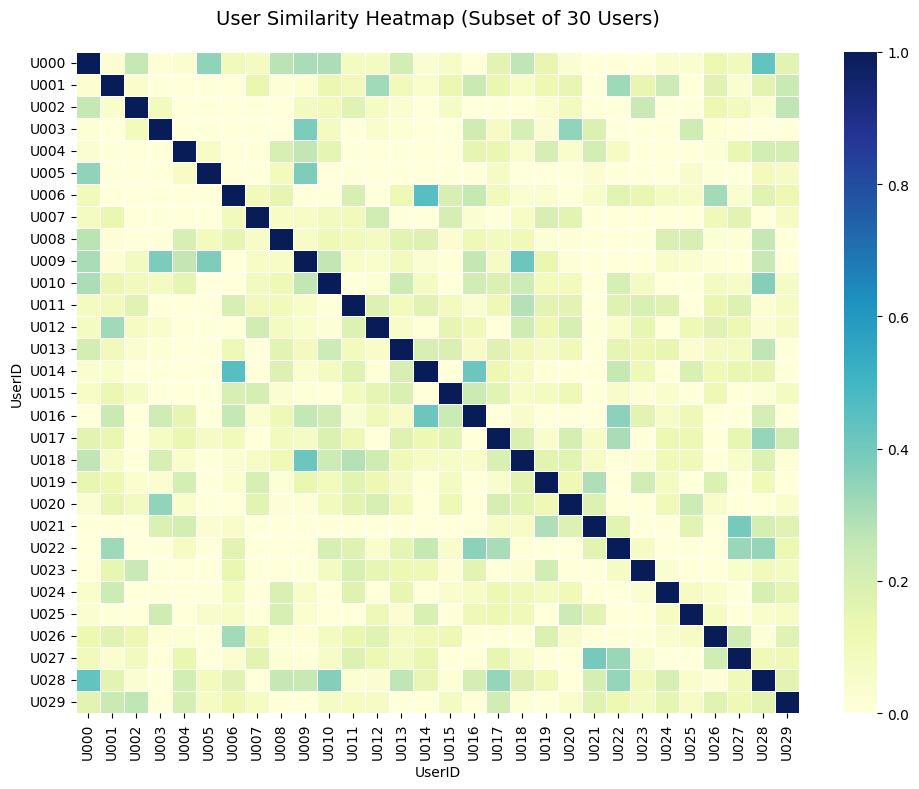

In [90]:
# User Similarity Heatmap
plt.figure(figsize=(10, 8))
# For readability, we will only plot a subset of the matrix (e.g., the first 30 users).
subset_similarity = train_similarity_df.iloc[:30, :30]

sns.heatmap(subset_similarity, cmap="YlGnBu", annot=False, linewidths=0.5)
plt.title("User Similarity Heatmap (Subset of 30 Users)", pad=20, fontsize=14)
plt.xlabel("UserID")
plt.ylabel("UserID")
plt.tight_layout()

plt.savefig(f"{RESULTS_PATH}/part5_user_similarity_heatmap.png", bbox_inches="tight")
plt.show()

**User Similarity Heatmap Analysis:**
The heatmap visually confirms the data sparsity discussed in Part 1. The vast majority of the plot is light-colored, indicating **low baseline similarity** between random users. However, the distinct dark squares (outside the diagonal) show small, tight-knit "neighborhoods" of users with highly correlated purchase behaviors. These are the clusters driving our collaborative filtering recommendations.

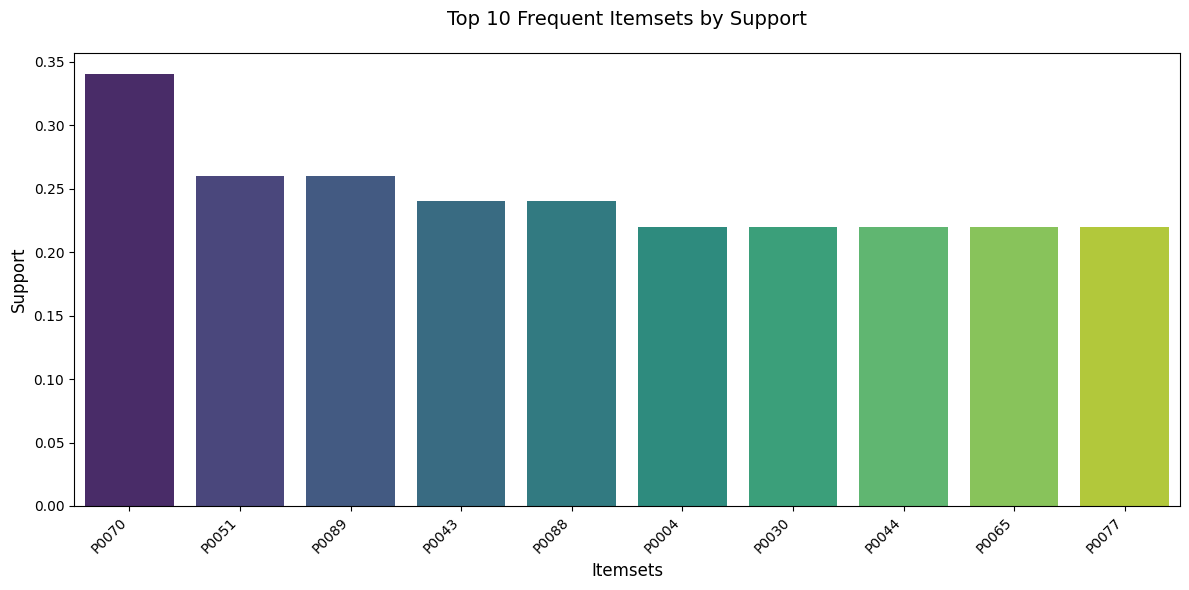

In [91]:
# Frequent Itemsets Bar Chart
if not frequent_itemsets.empty:
    # Get top 10 frequent itemsets
    top_itemsets = frequent_itemsets.nlargest(10, "support").copy()
    # Convert frozenset to string for plotting
    top_itemsets["itemsets_str"] = top_itemsets["itemsets"].apply(lambda x: ", ".join(list(x)))

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=top_itemsets,
        x="itemsets_str",
        y="support",
        hue="itemsets_str",
        palette="viridis",
        legend=False,
    )
    plt.title("Top 10 Frequent Itemsets by Support", pad=20, fontsize=14)
    plt.xlabel("Itemsets", fontsize=12)
    plt.ylabel("Support", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig(f"{RESULTS_PATH}/part5_top_10_frequent_itemsets.png", bbox_inches="tight")
    plt.show()

**Frequent Itemsets Bar Chart Analysis:**
This chart acts as a macro-view of overall platform trends. Item `P0070` is a clear platform driver, appearing in **over 34%** of all user interaction histories. This tells the business side that `P0070` is an ideal gateway product to use in acquisition ads.

In [92]:
# Top-5 Product Recommendations for a Sample of Users
# Generate clean summary tables for the first 5 users in our dataset
sample_users_for_recs = all_users[:5]
recs_summary_ids = []
recs_summary_names = []

for user in sample_users_for_recs:
    top_recs = get_user_recommendations(user, user_item_matrix_filled, similarity_df, top_n=5)

    # Store the raw Product IDs
    recs_summary_ids.append({"UserID": user, "Top 5 Recommendations (IDs)": ", ".join(top_recs)})

    # Fetch product names for better interpretability
    rec_names = []
    for product_id in top_recs:
        # Check if product exists in details, otherwise just use ID
        name_match = product_data[product_data["ProductID"] == product_id]["ProductName"]
        name = name_match.values[0] if not name_match.empty else product_id
        rec_names.append(name)

    recs_summary_names.append(
        {"UserID": user, "Top 5 Recommendations (Names)": ", ".join(rec_names)}
    )

# Create DataFrames
df_ids = pd.DataFrame(recs_summary_ids)
df_names = pd.DataFrame(recs_summary_names)

# Display the results
with pd.option_context("display.max_colwidth", None):
    print("Table 1: Recommendations Output (Raw Product IDs)")
    display(df_ids.style.set_properties(**{"text-align": "left"}))

    print("=" * 80 + "\n")

    print("Table 2: Recommendations Output (Translated Product Names)")
    display(df_names.style.set_properties(**{"text-align": "left", "align": "center"}))

Table 1: Recommendations Output (Raw Product IDs)


,UserID,Top 5 Recommendations (IDs)
0,U000,"P0029, P0030, P0032, P0041, P0062"
1,U001,"P0046, P0060, P0061, P0063, P0071"
2,U002,"P0033, P0041, P0009, P0032, P0034"
3,U003,"P0017, P0021, P0025, P0030, P0048"
4,U004,"P0024, P0032, P0033, P0036, P0041"



Table 2: Recommendations Output (Translated Product Names)


,UserID,Top 5 Recommendations (Names)
0,U000,"Books Item 29, Books Item 30, Toys Item 32, Books Item 41, Books Item 62"
1,U001,"Home Item 46, Toys Item 60, Clothing Item 61, Beauty Item 63, Beauty Item 71"
2,U002,"Toys Item 33, Books Item 41, Clothing Item 9, Toys Item 32, Beauty Item 34"
3,U003,"Beauty Item 17, Electronics Item 21, Clothing Item 25, Books Item 30, Electronics Item 48"
4,U004,"Beauty Item 24, Toys Item 32, Toys Item 33, Beauty Item 36, Books Item 41"


**Recommendation Outputs Analysis:**
Looking at our translated Top-5 table, the recommendations intuitively align with the category behavior we aggregated in Part 1. For example, `U000` receives recommendations entirely in the "Books" and "Toys" categories, perfectly matching their historical preference profile.